# CSDA STAC search for Evaluation Sites

Paul Montesano, PhD  
March 2026

In [83]:
#pip install contextily
#pip install matplotlib_scalebar

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from urllib.parse import quote
import numpy as np

import sys

sys.path.append('/projects/code/csda_summaries/lib')
sys.path.append('/projects/code/geoscitools')
sys.path.append('/home/pmontesa/code/csda_summaries/lib')
sys.path.append('/home/pmontesa/code/geoscitools')

import csdalib
import staclib

from datetime import datetime
from multiprocessing import Pool, cpu_count
from functools import partial
from tqdm import tqdm
import importlib

/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_1935103/1514043613.py:2: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/li

# Read in Evaluation Sites

In [2]:
# Define your spreadsheet ID and sheet name
SPREADSHEET_ID = '13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k'
BUF_KM = 10

In [3]:
SHEET_NAME = 'Evaluation Sites' # The name of the specific tab

# 2. Encode the sheet name for safe use in a URL
ENCODED_SHEET_NAME = quote(SHEET_NAME)

# 3. Construct the full URL using the gviz/tq endpoint
url = f"https://docs.google.com/spreadsheets/d/{SPREADSHEET_ID}/gviz/tq?tqx=out:csv&sheet={ENCODED_SHEET_NAME}"

# 4. Use pandas to read the CSV data directly from the URL
try:
    sites = pd.read_csv(url)
    sites['Site Name'] = sites['Site Name abbrev'].str.rstrip()
    
except Exception as e:
    print(f"An error occurred: {e}")

sites_gdf = gpd.GeoDataFrame(
        sites,
        geometry=gpd.points_from_xy(sites['Longitude'], sites['Latitude']),
        crs="EPSG:4326"
    )
# Buffer and drop empty geoms
sites_gdf = csdalib.buffer_site_gdf(sites_gdf, BUF_KM)
sites_gdf = sites_gdf[~sites_gdf.geometry.is_empty]

# Get the list of columns to drop
cols_to_drop = sites_gdf.columns[sites_gdf.columns.str.contains('Unnamed')]
sites_gdf = sites_gdf.drop(columns=cols_to_drop)

In [4]:
### Buffer MORE for sites for display
BUF_KM_ADD_FOR_DISPLAY = 70
BUF_KM_TOTAL_FOR_DISPLAY = BUF_KM_ADD_FOR_DISPLAY + BUF_KM

In [5]:
sites_gdf_buf = sites_gdf.to_crs(3857).buffer(BUF_KM_ADD_FOR_DISPLAY * 1000) # add arbitrary buffer to evaluation sites for map display
sites_gdf_buf_display = gpd.GeoDataFrame(sites_gdf.drop(columns=['geometry']), geometry=sites_gdf_buf, crs=sites_gdf_buf.crs).to_crs(4326)
sites_gdf_buf_display = sites_gdf_buf_display[~(sites_gdf_buf_display.geometry.is_empty | sites_gdf_buf_display.geometry.isna())]

# List CSDA STAC Collections

In [6]:
import requests
from IPython.display import Markdown, display

STAC_API_URL = 'https://csdap.earthdata.nasa.gov/stac'

# Get collections
response = requests.get(f'{STAC_API_URL}/collections')
data = response.json()

collections = data.get('collections', [])

# Build markdown
markdown_output = f"# CSDA STAC Collections\n\n"
markdown_output += f"**Total Collections:** {len(collections)}\n\n"
markdown_output += "| ID | Title | Description | Temporal Coverage |\n"
markdown_output += "|:---|:---|:---|:---|\n"

for collection in collections:
    col_id = collection.get('id', 'N/A')
    title = collection.get('title', 'N/A')
    description = collection.get('description', 'N/A')
    
    # Truncate and clean description
    if description and description != 'N/A':
        description = description.replace('\n', ' ').replace('\r', '')
        if len(description) > 100:
            description = description[:100] + '...'
        description = description.replace('|', '\\|')
    
    # Get temporal extent with safe None checks
    temporal_str = 'N/A'
    try:
        extent = collection.get('extent')
        if extent and isinstance(extent, dict):
            temporal = extent.get('temporal')
            if temporal and isinstance(temporal, dict):
                intervals = temporal.get('interval', [])
                if intervals and isinstance(intervals, list) and len(intervals) > 0:
                    if intervals[0] and isinstance(intervals[0], list) and len(intervals[0]) > 0:
                        start = intervals[0][0] if intervals[0][0] else 'Unknown'
                        end = intervals[0][1] if len(intervals[0]) > 1 and intervals[0][1] else 'Present'
                        
                        # Format dates nicely
                        if isinstance(start, str) and start not in ['Unknown', 'N/A']:
                            start = start.split('T')[0]
                        if isinstance(end, str) and end not in ['Present', 'N/A']:
                            end = end.split('T')[0]
                        
                        temporal_str = f"{start} to {end}"
    except Exception as e:
        # If anything goes wrong, just leave as N/A
        pass
    
    # Create collection link
    collection_url = f"{STAC_API_URL}/collections/{col_id}"
    col_id_link = f"[{col_id}]({collection_url})"
    
    markdown_output += f"| {col_id_link} | {title} | {description} | {temporal_str} |\n"

# Display in notebook
display(Markdown(markdown_output))

# Save to file
with open('stac_collections.md', 'w') as f:
    f.write(markdown_output)

print("\n✓ Saved to stac_collections.md")

# CSDA STAC Collections

**Total Collections:** 16

| ID | Title | Description | Temporal Coverage |
|:---|:---|:---|:---|
| [geooptics](https://csdap.earthdata.nasa.gov/stac/collections/geooptics) | GeoOptics | geooptics | N/A |
| [capellaspace](https://csdap.earthdata.nasa.gov/stac/collections/capellaspace) | CapellaSpace | capellaspace | N/A |
| [desis](https://csdap.earthdata.nasa.gov/stac/collections/desis) | DESIS | Teledyne Brown Engineering, Inc – DESIS | 2018-11-21 to 2024-05-31 |
| [planet](https://csdap.earthdata.nasa.gov/stac/collections/planet) | Planet | Planet | N/A |
| [spire](https://csdap.earthdata.nasa.gov/stac/collections/spire) | Spire | Spire | N/A |
| [umbra](https://csdap.earthdata.nasa.gov/stac/collections/umbra) | Umbra | Umbra Space | 2024-01-01 to 2025-07-31 |
| [iceye](https://csdap.earthdata.nasa.gov/stac/collections/iceye) | Iceye | ICEYE US | 2019-01-01 to 2024-12-31 |
| [ghgsat](https://csdap.earthdata.nasa.gov/stac/collections/ghgsat) | GHGSat | GHGSat | 2011-01-01 to Present |
| [blacksky](https://csdap.earthdata.nasa.gov/stac/collections/blacksky) | Blacksky | blacksky | N/A |
| [pgc-earthdem](https://csdap.earthdata.nasa.gov/stac/collections/pgc-earthdem) | EarthDEM | EarthDEM | 2003-01-01 to Present |
| [maxar-sdx](https://csdap.earthdata.nasa.gov/stac/collections/maxar-sdx) | Maxar DEM | Maxar Technologies – Precision 3D | 2010-01-01 to 2025-09-29 |
| [planetiq](https://csdap.earthdata.nasa.gov/stac/collections/planetiq) | PlanetiQ | PlanetiQ | 2024-01-01 to 2024-12-31 |
| [tomorrow](https://csdap.earthdata.nasa.gov/stac/collections/tomorrow) | Tomorrow | The Tomorrow Companies Inc. | 2023-01-01 to 2025-08-15 |
| [maxar-legion](https://csdap.earthdata.nasa.gov/stac/collections/maxar-legion) | Maxar Legion | Maxar Technologies Inc. | 2024-01-01 to 2025-08-13 |
| [satellogic](https://csdap.earthdata.nasa.gov/stac/collections/satellogic) | Satellogic | Satellogic Inc. | Unknown to Present |
| [airbus](https://csdap.earthdata.nasa.gov/stac/collections/airbus) | Airbus U.S.- SAR | Airbus U.S. | 2007-01-02 to Present |



✓ Saved to stac_collections.md


### Create site dicts for all sites

In [7]:
site_dicts = staclib.create_site_dict_from_gdf(sites_gdf, site_name_field = 'Site Name', buffer_degrees=0.1)

# Multiprocess search across all CSDA Evaluation Sites for a vendor

### Configure search

In [8]:
COLLECTION_LIST = ['maxar-legion']
START_OF_COMMERCIAL_ERA = '1999-01-01'
TODAY = datetime.now().strftime('%Y-%m-%d')

# START_DATE = '2010-01-01'
# END_DATE = '2025-01-21'#'2024-10-31' # last date of data used for original Satellogic eval

# START_DATE = '2025-01-21'#'2024-10-31' # last date of data used for original Satellogic eval
# END_DATE = TODAY

START_DATE = START_OF_COMMERCIAL_ERA
END_DATE = TODAY

CSDA_EVAL_SITE_ITEMS = list(site_dicts.items())

### Multiprocess SDX search across CSDA Eval sites

In [9]:
search_func = partial(staclib.stac_search_site, end_date=END_DATE, start_date=START_DATE, 
                      collections=COLLECTION_LIST
                     )
#search_func = partial(search_site, today=today, start_date='2010-01-01', collections=['maxar'])

n_processes = max(1, cpu_count() - 1)
print(f"Using {n_processes} processes to search {len(CSDA_EVAL_SITE_ITEMS)} sites\n")

# Run with progress bar
with Pool(processes=n_processes) as pool:
    results = list(tqdm(
        pool.imap(search_func, CSDA_EVAL_SITE_ITEMS),
        total=len(CSDA_EVAL_SITE_ITEMS),
        desc="Searching sites"
    ))

# Collect and report results
stac_gdf_list = []
print("\nResults by site:")
for site_name, gdf, message in results:
    print(f"  {site_name}: {message}")
    if gdf is not None:
        stac_gdf_list.append(gdf)

# Combine
if stac_gdf_list:
    stac_gdf = pd.concat(stac_gdf_list, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Total: {len(stac_gdf)} items from {stac_gdf['site_name'].nunique()} sites")
    print(f"{'='*60}")
    print("\nItems per site:")
    print(stac_gdf['site_name'].value_counts())
else:
    print("\nNo items found")
    stac_gdf = gpd.GeoDataFrame()

Using 39 processes to search 98 sites



Searching sites: 100%|██████████| 98/98 [00:07<00:00, 13.41it/s]


Results by site:
  Albuquerque: No items found
  Baotou: No items found
  Belo Horizonte: No items found
  Boston: No items found
  Cape Town: No items found
  Casablanca: No items found
  Caspian Sea: No items found
  Catania: No items found
  Crater Lake: No items found
  Cuprite: No items found
  Dublin: No items found
  Gobabeb: No items found
  Hinton: No items found
  Hohhot: No items found
  King Fahd Causeway: No items found
  La Crau: Found 2 items
  Lake Pontchartrain Causeway: No items found
  London: No items found
  Melbourne: Found 2 items
  Navarre Causeway: No items found
  Neustrelitz: No items found
  Old Bahia Bridge: No items found
  Phoenix: No items found
  PICS Algeria-3: No items found
  PICS Libya-1: No items found
  PICS Libya-4: Found 14 items
  Piedmont: No items found
  Railroad Valley: No items found
  Rio Gallegos: No items found
  Rosamond: No items found
  Salon-de-Provence: Found 16 items
  Sapporo: Found 2 items
  Suramadu Bridge: No items found
  Sh

## SDX acquisitions

In [10]:
stac_gdf = stac_gdf.drop(columns=[col for col in stac_gdf.columns if 'asset' in col])

21 M2AS|M3DS maxar-legion acquisitions on SDX


/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).
  warnings.warn(msg)


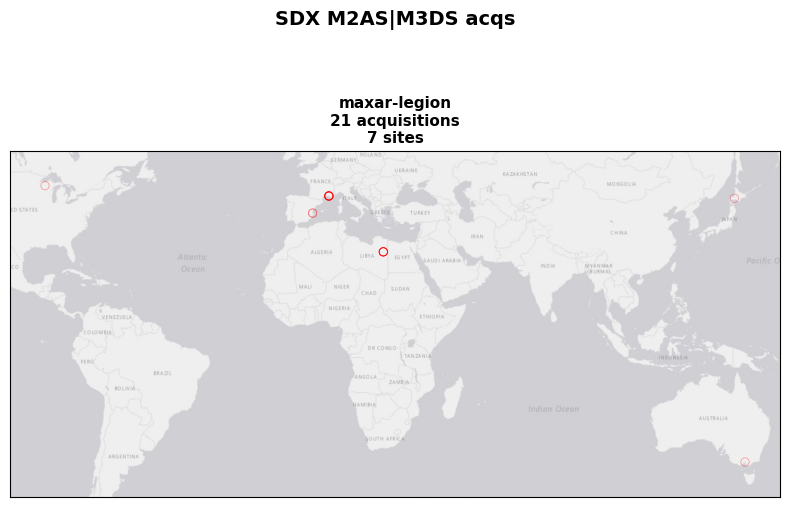

In [11]:
# Only look at multispec records for now
PROD_SEARCH_STR = 'M2AS|M3DS'
stac_gdf_sub = stac_gdf[stac_gdf['id'].str.contains(PROD_SEARCH_STR, na=False)]
print(f"{stac_gdf_sub.shape[0]} {PROD_SEARCH_STR} {COLLECTION_LIST[0]} acquisitions on SDX")

fig = staclib.plot_collections_map(stac_gdf_sub, show_stats=True, collection_field='collection', suptitle=f"SDX {PROD_SEARCH_STR} acqs")
plt.show()

In [20]:
PROD_SEARCH_STR = 'S3DS'
stac_gdf_sub = stac_gdf[stac_gdf['id'].str.contains(PROD_SEARCH_STR, na=False)]
print(f"{stac_gdf_sub.shape[0]} {PROD_SEARCH_STR} {COLLECTION_LIST[0]} acquisitions on SDX")

if len(stac_gdf_sub) >0:
    fig = staclib.plot_collections_map(stac_gdf_sub, show_stats=True, collection_field='collection', suptitle=f"SDX {PROD_SEARCH_STR} acqs")
    plt.show()

0 S3DS maxar-legion acquisitions on SDX


## ADAPT acquisitions

In [13]:
adapt_gdf = gpd.read_file('/explore/nobackup/projects/CSDA_eval/footprints/footprints_CSDA_eval_ACQUISITIONS_latest.gpkg')
adapt_gdf = adapt_gdf[(adapt_gdf.constellation == 'Legion')]
adapt_gdf.shape

(97, 21)

23 M2AS|M3DS maxar-legion acquisitions on ADAPT


/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).
  warnings.warn(msg)


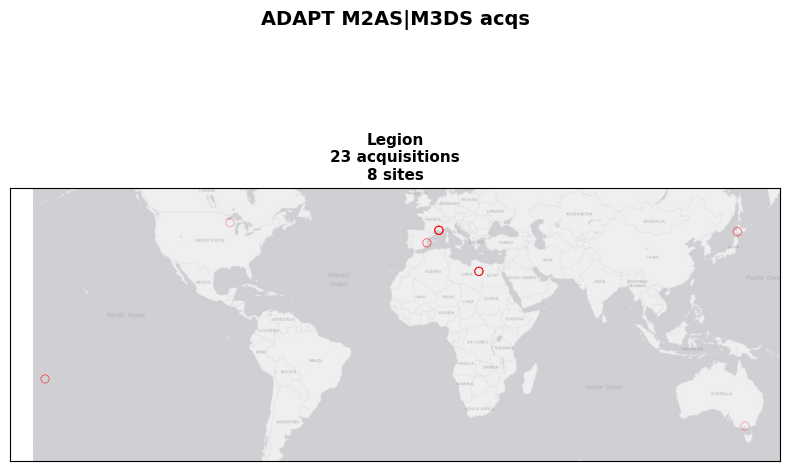

In [15]:
# Only look at multispec records for now
PROD_SEARCH_STR = 'M2AS|M3DS'
adapt_gdf_sub = adapt_gdf[adapt_gdf['acquisition_id'].str.contains(PROD_SEARCH_STR, na=False)]
print(f"{adapt_gdf_sub.shape[0]} {PROD_SEARCH_STR} {COLLECTION_LIST[0]} acquisitions on ADAPT")

fig = staclib.plot_collections_map(adapt_gdf_sub, show_stats=True, collection_field='constellation', suptitle=f"ADAPT {PROD_SEARCH_STR} acqs", site_name_field='Site_Primary')
plt.show()

39 S3DS maxar-legion acquisitions on ADAPT


/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).
  warnings.warn(msg)


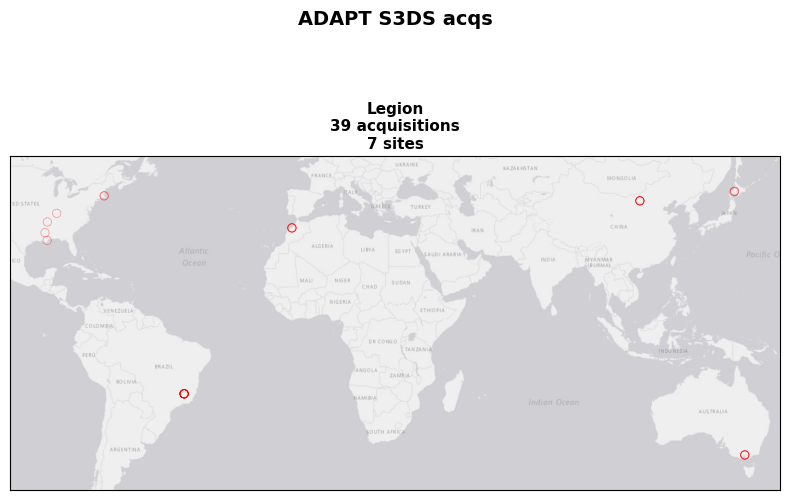

In [17]:
PROD_SEARCH_STR = 'S3DS'
adapt_gdf_sub = adapt_gdf[adapt_gdf['acquisition_id'].str.contains(PROD_SEARCH_STR, na=False)]
print(f"{adapt_gdf_sub.shape[0]} {PROD_SEARCH_STR} {COLLECTION_LIST[0]} acquisitions on ADAPT")

fig = staclib.plot_collections_map(adapt_gdf_sub, show_stats=True, collection_field='constellation', suptitle=f"ADAPT {PROD_SEARCH_STR} acqs", site_name_field='Site_Primary')
plt.show()

In [18]:
print(f"SDX has {stac_gdf_sub.shape[0] - adapt_gdf_sub.shape[0]} {COLLECTION_LIST[0]} acquisitions compared to what we have on ADAPT")

SDX has -39 maxar-legion acquisitions compared to what we have on ADAPT


#### Note: Legion data on SDX STAC does not include `S3DS` product code

In [19]:
print(stac_gdf.id.to_list()) # just 'P3DS' and 'M3DS'

['200009817627_01_P001_P3DS', '200009817627_01_P001_M3DS', '200010964783_01_P001_P3DS', '200010964783_01_P001_M3DS', '200009817650_01_P001_P3DS', '200009817650_01_P001_M3DS', '200009817649_01_P001_P3DS', '200009817649_01_P001_M3DS', '200009817651_01_P001_P3DS', '200009817651_01_P001_M3DS', '200009817645_01_P001_P3DS', '200009817645_01_P001_M3DS', '200009817643_01_P001_P3DS', '200009817643_01_P001_M3DS', '200009817644_01_P001_P3DS', '200009817644_01_P001_M3DS', '200009817641_01_P001_P3DS', '200009817641_01_P001_M3DS', '200009817622_01_P001_P3DS', '200009817622_01_P001_M3DS', '200009817623_01_P001_P3DS', '200009817623_01_P001_M3DS', '200009817624_01_P001_P3DS', '200009817624_01_P001_M3DS', '200009817627_01_P001_P3DS', '200009817627_01_P001_M3DS', '200009817629_01_P001_P3DS', '200009817629_01_P001_M3DS', '200009817634_01_P001_P3DS', '200009817634_01_P001_M3DS', '200009817636_01_P001_P3DS', '200009817636_01_P001_M3DS', '200009817637_01_P001_P3DS', '200009817637_01_P001_M3DS', '200010867968

# Plot maps of sites and their acqs (static)

## Overview map of STAC collections at evaluation sites

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).
  warnings.warn(msg)


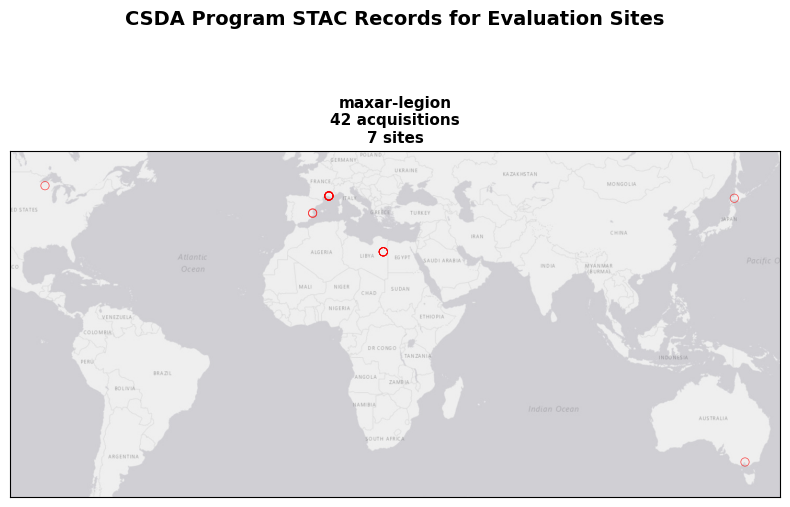

In [21]:
fig = staclib.plot_collections_map(stac_gdf, show_stats=True)
plt.show()

### Plot site maps for acquisitions

In [23]:
# import sensor_lookup_table
# SENSOR_LOOKUP = sensor_lookup_table.SENSOR_LOOKUP['LEGION']

Plotting 2 acquisitions for La Crau
Found 14 additional acquisitions in buffer zone


/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Plotting 2 acquisitions for Melbourne
Found 0 additional acquisitions in buffer zone
Plotting 14 acquisitions for PICS Libya-4
Found 0 additional acquisitions in buffer zone
Plotting 16 acquisitions for Salon-de-Provence
Found 0 additional acquisitions in buffer zone
Plotting 2 acquisitions for Sapporo
Found 0 additional acquisitions in buffer zone
Plotting 4 acquisitions for Valencia
Found 0 additional acquisitions in buffer zone
Plotting 2 acquisitions for WLEF
Found 0 additional acquisitions in buffer zone


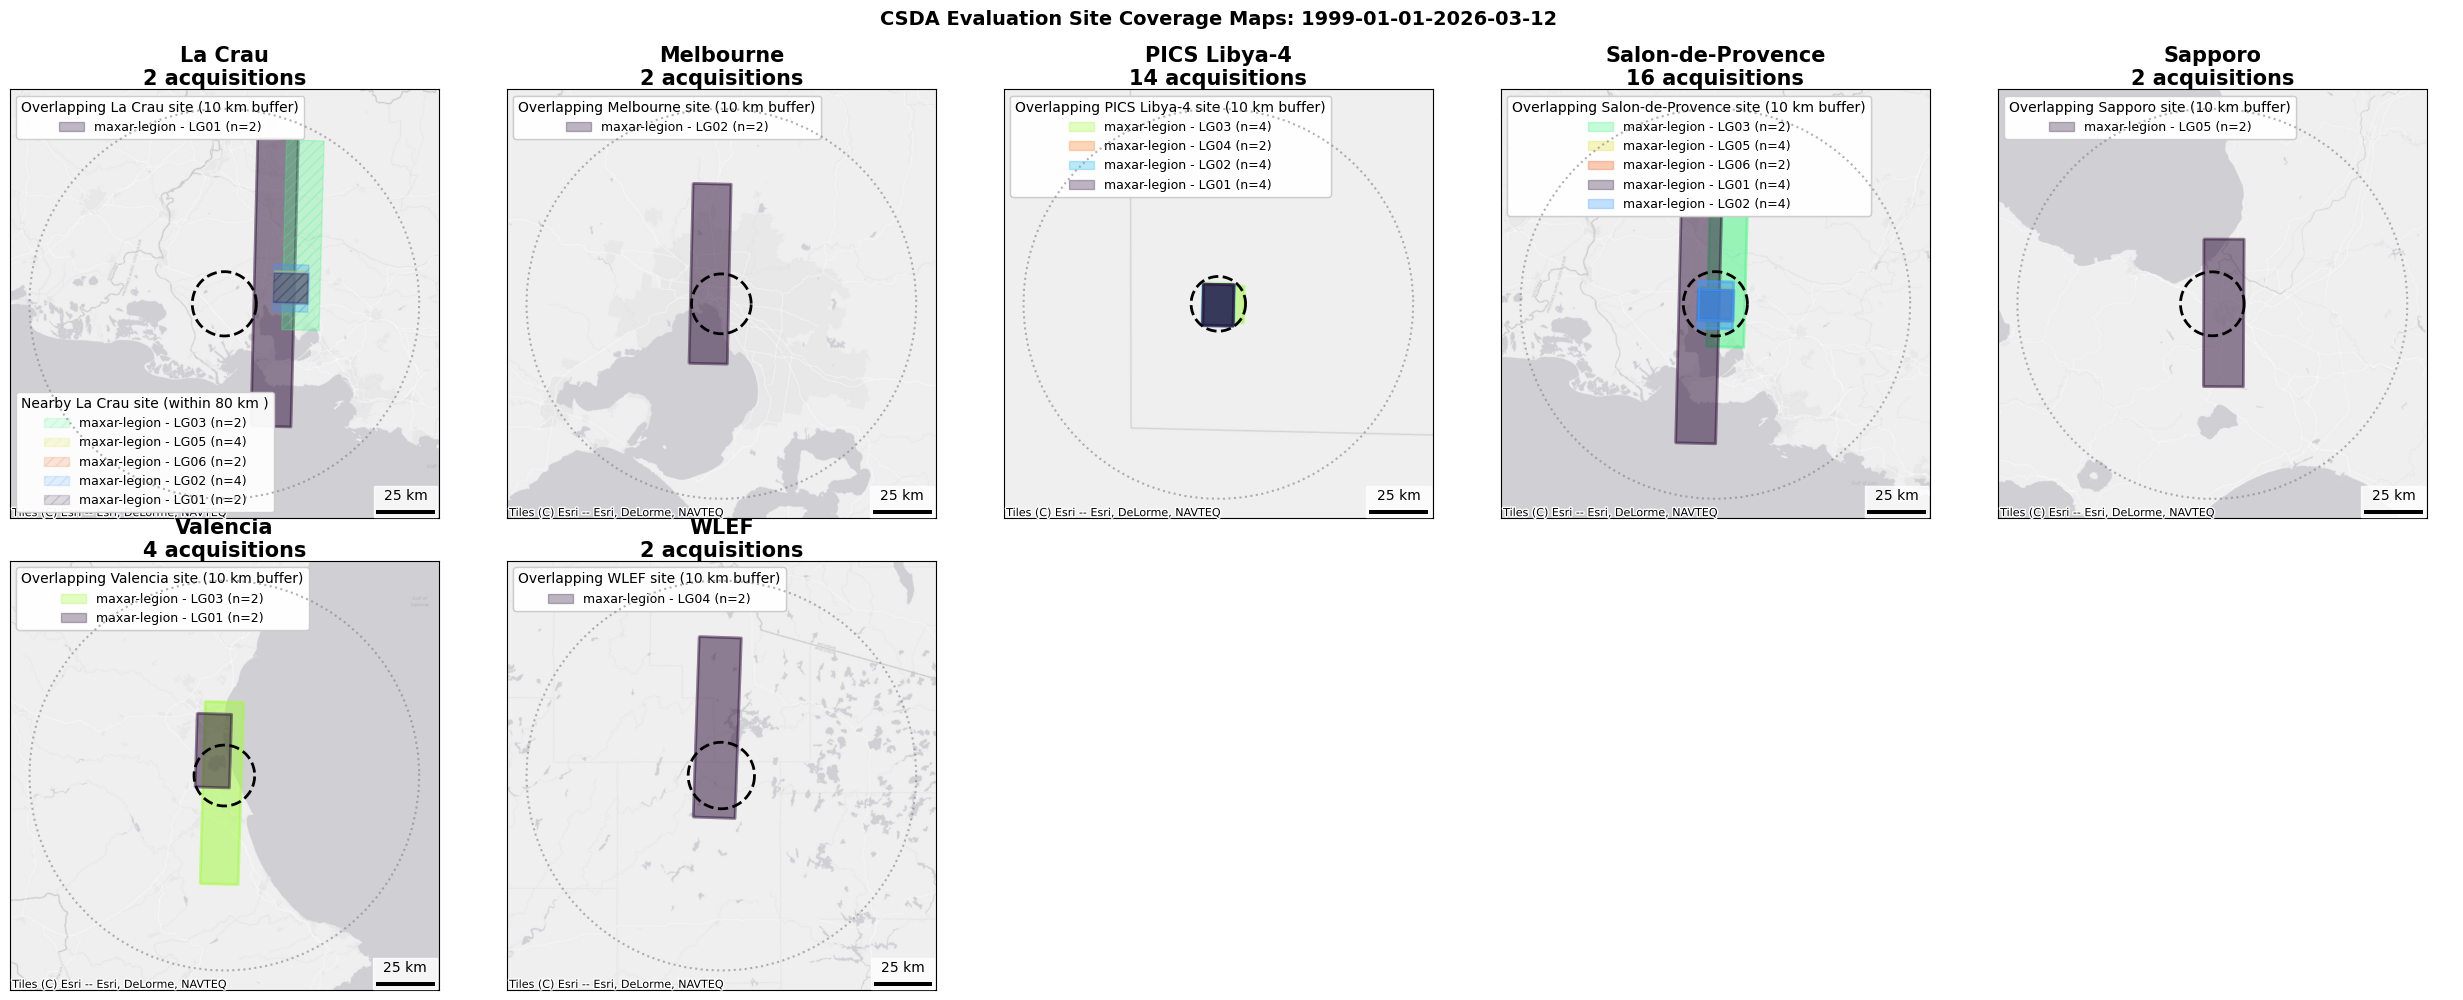

In [24]:
# Define gdf to plot
gdf_to_plot = stac_gdf

# Define sites to plot
sites_to_plot = sorted([site for site in gdf_to_plot.site_name.unique() if site != 'Not CSDA Eval Site'])

# Create grid
n_sites = len(sites_to_plot)
n_cols = 5
n_rows = int(np.ceil(n_sites / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols,5 * n_rows))

# Flatten axes
if n_sites == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Plot each site
for idx, site_name in enumerate(sites_to_plot):
    csdalib.plot_site_coverage(site_name, 
                      gdf_to_plot, 
                      sites_gdf, 
                      BUF_KM, 
                       BUF_KM_TOTAL_FOR_DISPLAY,
                      sites_buf_gdf=sites_gdf_buf_display,
                      site_name_field = 'site_name',
                               
                        # Satellogic
                        id_field = 'id', 
                        affiliation_field = 'collection',
                        constellation_field = 'platform',
                               
                      ax=axes[idx])  # Pass the axis here

# Hide unused subplots
for idx in range(n_sites, len(axes)):
    axes[idx].axis('off')

# Add main title
plt.suptitle(f"CSDA Evaluation Site Coverage Maps: {START_DATE}-{END_DATE}", fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

## Heatmaps provides info on amount of overlap at a site

#### static, all sites for each collection

Calculating global count range...
Global count range: 1 - 16


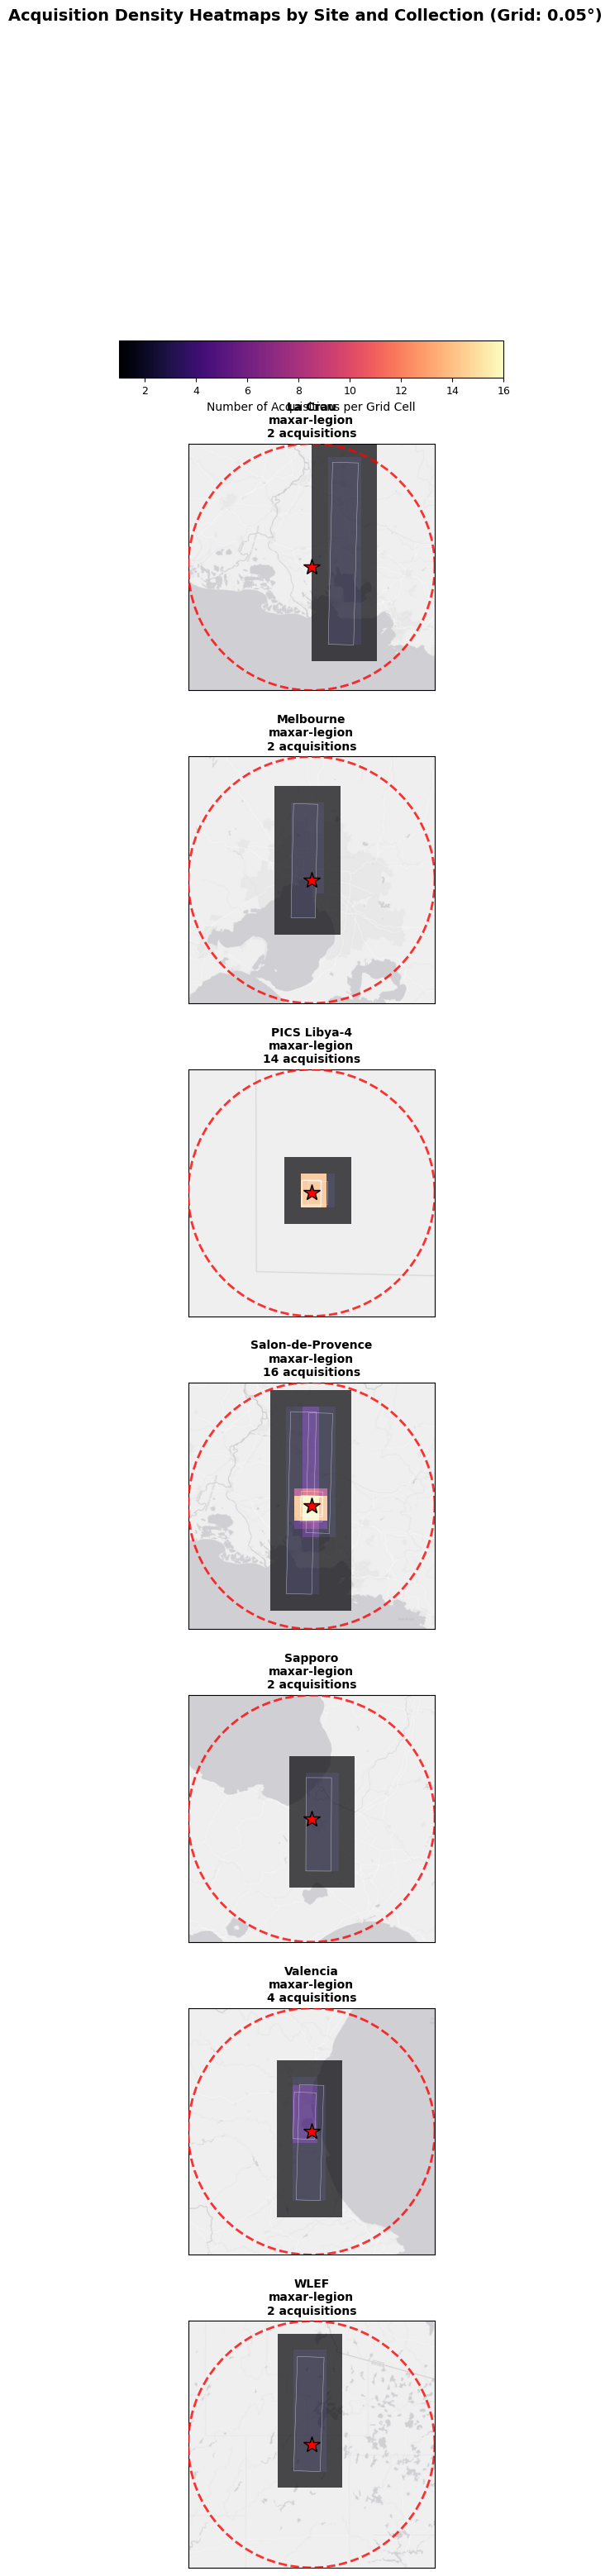

In [25]:
# Use it
all_grids, fig = staclib.create_acquisition_heatmap_multi(
    stac_gdf,
    sites_gdf,
    sites_gdf_buf_display,
    site_name_field='site_name',
    site_name_field_sites='Site Name',
    # collections=['planet', 'satellogic'],
    # sites=['PICS Libya-4', 'Casablanca'],
    collections=COLLECTION_LIST,
    sites=None,
    grid_size=0.05,
    cmap='magma'
)

plt.show()

#### interactive for 1 site, collection

In [26]:
m, grid_gdf = staclib.create_interactive_heatmap(
    stac_gdf,
    collection_name=COLLECTION_LIST[0],
    grid_size=0.01,
    cmap='magma',
    site_name='PICS Libya-4'
)

# m.save('libya4_satellogic_heatmap.html')
m

Creating heatmap for 14 acquisitions
Grid cells with data: 380
Acquisition count range: 1 - 14
